In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Find repo root = folder that contains "citylearn/"
HERE = Path.cwd()
REPO_DIR = None
for p in [HERE] + list(HERE.parents):
    if (p / "citylearn").exists():
        REPO_DIR = p
        break

if REPO_DIR is None:
    raise FileNotFoundError(
        "Couldn't find the repo root (a folder containing 'citylearn'). "
        "Make sure you cloned the repo and opened the notebook from somewhere inside it."
    )

# 2) Force local CityLearn (repo version)
sys.path.insert(0, str(REPO_DIR))
import citylearn
print("✅ citylearn loaded from:", citylearn.__file__)
print("✅ repo root:", REPO_DIR)

# 3) Dataset paths
CLIMATE = "VT"  # "TX" or "VT"
DATASET_DIR = REPO_DIR / "data" / "datasets" / f"annex96_ce1_{CLIMATE.lower()}_neighborhood"
SCHEMA_PATH = DATASET_DIR / "schema.json"

print("\nClimate:", CLIMATE)
print("Dataset directory:", DATASET_DIR, " | exists:", DATASET_DIR.exists())
print("Schema path:", SCHEMA_PATH, " | exists:", SCHEMA_PATH.exists())


✅ citylearn loaded from: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/__init__.py
✅ repo root: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1

Climate: VT
Dataset directory: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/data/datasets/annex96_ce1_vt_neighborhood  | exists: True
Schema path: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/data/datasets/annex96_ce1_vt_neighborhood/schema.json  | exists: True


In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from citylearn.citylearn import CityLearnEnv

# ----------------------------
# 1) Month -> (start,end) hour-of-year (inclusive end)
# ----------------------------
DAYS_IN_MONTH = [31,28,31,30,31,30,31,31,30,31,30,31]

def month_range(month: int):
    """
    month: 1..12
    returns (start, end) in hour-of-year, end is inclusive
    """
    assert 1 <= month <= 12
    start_day = sum(DAYS_IN_MONTH[:month-1])
    end_day   = start_day + DAYS_IN_MONTH[month-1] - 1
    start = start_day * 24
    end   = (end_day + 1) * 24 - 1
    return start, end

# Examples:
# Jan: month_range(1) -> (0, 743)
# Feb: month_range(2) -> (744, 1415)
# Jun: month_range(6) -> (3624, 4343)
# Jul: month_range(7) -> (4344, 5087)

# ----------------------------
# 2) Make a schema copy with a given time window
# ----------------------------
def write_schema_with_window(schema_in: Path, schema_out: Path, start_ts: int, end_ts: int):
    d = json.loads(Path(schema_in).read_text())
    d["simulation_start_time_step"] = int(start_ts)
    d["simulation_end_time_step"] = int(end_ts)
    # good practice: force episode_time_steps to match the window
    d["episode_time_steps"] = int(end_ts - start_ts + 1)
    schema_out.write_text(json.dumps(d, indent=2))
    return schema_out

# ----------------------------
# 3) Load target slice for a month window
# ----------------------------
def slice_target_for_window(district_target_full: np.ndarray, start_ts: int, end_ts: int):
    return district_target_full[start_ts:end_ts+1]


Couldn't import dot_parser, loading of dot files will not be possible.


In [3]:
def get_train_test_months(CLIMATE: str):
    CLIMATE = CLIMATE.upper()
    if CLIMATE == "VT":
        return 1, 2   # Jan train, Feb test
    elif CLIMATE == "TX":
        return 6, 7   # Jun train, Jul test
    else:
        raise ValueError("CLIMATE must be 'TX' or 'VT'")


In [4]:
# ---- inputs you already have ----
# SCHEMA_PATH, DATASET_DIR, CLIMATE

# Load full-year target once
df = pd.read_csv(DATASET_DIR / "district_target.csv")
district_target_full = df["district_load_target"].to_numpy(float)

train_m, test_m = get_train_test_months(CLIMATE)

train_start, train_end = month_range(train_m)
test_start, test_end   = month_range(test_m)

# Write two schema files (train/test)
SCHEMA_TRAIN = Path(SCHEMA_PATH).with_name(f"{Path(SCHEMA_PATH).stem}_TRAIN.json")
SCHEMA_TEST  = Path(SCHEMA_PATH).with_name(f"{Path(SCHEMA_PATH).stem}_TEST.json")

write_schema_with_window(Path(SCHEMA_PATH), SCHEMA_TRAIN, train_start, train_end)
write_schema_with_window(Path(SCHEMA_PATH), SCHEMA_TEST,  test_start,  test_end)

# Slice targets to match each env exactly
target_train = slice_target_for_window(district_target_full, train_start, train_end)
target_test  = slice_target_for_window(district_target_full, test_start,  test_end)

print("Train steps:", len(target_train), "time steps:", train_start, train_end)
print("Test  steps:", len(target_test),  "time steps:", test_start,  test_end)

# Create envs
env_train = CityLearnEnv(schema=str(SCHEMA_TRAIN), root_directory=str(DATASET_DIR), central_agent=False)
env_test  = CityLearnEnv(schema=str(SCHEMA_TEST),  root_directory=str(DATASET_DIR), central_agent=False)

assert env_train.time_steps == len(target_train)
assert env_test.time_steps  == len(target_test)


Train steps: 744 time steps: 0 743
Test  steps: 672 time steps: 744 1415


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

In [5]:
import numpy as np
from citylearn.citylearn import CityLearnEnv

def get_baseline_episode(schema_path, dataset_dir, central_agent=True):
    """
    Baseline trajectory: run the environment with ALL actions = 0.
    Returns:
        y_baseline: np.ndarray of district net electricity consumption (len = env.time_steps)
        env: the finished env (optional, useful for debugging)
    """
    env = CityLearnEnv(
        schema=str(schema_path),
        root_directory=str(dataset_dir),
        central_agent=central_agent
    )

    obs, _ = env.reset()

    # zero actions for central-agent interface
    if central_agent:
        zero_action = [0.0] * len(env.action_names[0])
        while not env.terminated:
            obs, _, _, _, _ = env.step([zero_action])
    else:
        # zero actions for decentralized interface
        zero_actions = [[0.0] * len(env.action_names[i]) for i in range(len(env.action_names))]
        while not env.terminated:
            obs, _, _, _, _ = env.step(zero_actions)

    return np.array(env.net_electricity_consumption, dtype=float), env


In [19]:
from citylearn.citylearn import CityLearnEnv
import numpy as np

baseline_train, _ = get_baseline_episode(
    schema_path=SCHEMA_TRAIN,
    dataset_dir=DATASET_DIR,
    central_agent=False
)

baseline_test, _ = get_baseline_episode(
    schema_path=SCHEMA_TEST,
    dataset_dir=DATASET_DIR,
    central_agent=False
)

# One place to store everything (no repetition later)
EPISODES = {
    "train": {"schema": SCHEMA_TRAIN, "target": target_train, "baseline": baseline_train},
    "test":  {"schema": SCHEMA_TEST,  "target": target_test,  "baseline": baseline_test},
}

def run_controller(split, central_agent, make_agent_fn, climate, name="controller"):
    """
    Runs a controller on the chosen split ('train' or 'test') and returns metrics.
    Automatically uses the matching schema + target.
    """
    schema_path = EPISODES[split]["schema"]
    target_episode = EPISODES[split]["target"]

    env = CityLearnEnv(
        schema=str(schema_path),
        root_directory=str(DATASET_DIR),
        central_agent=central_agent
    )
    obs, info = env.reset()
    agent = make_agent_fn(env, split=split)  # split passed in case agent needs baseline

    while not env.terminated:
        actions = agent.predict(obs)
        obs, reward, terminated, truncated, info = env.step(actions)

    # y = np.asarray(env.net_electricity_consumption, float)
    # y, r = align(y, target_episode)
    
    y_raw = np.asarray(env.net_electricity_consumption, float)
    y_clipped = np.maximum(y_raw, 0.0)

        # ----------------------------
    # Metrics
    # ----------------------------
    y = y_clipped
    r = target_episode[:len(y)]

    # NMBE [%]
    nmbe = 100.0 * np.sum(y - r) / np.sum(r)

    # CVRMSE [%]
    cvrmse = 100.0 * np.sqrt(np.mean((y - r)**2)) / np.mean(r)

    # Temperature exceedances
    B = len(env.buildings)
    exceed_hours = np.zeros(B)
    exceed_pct   = np.zeros(B)

    for b in range(B):
        T = np.asarray(env.buildings[b].indoor_dry_bulb_temperature, float)
        if climate.upper() == "TX":
            Tlo, Thi = 22.0, 26.0
        else:
            Tlo, Thi = 20.0, 24.0

        exceed = np.logical_or(T < Tlo, T > Thi)
        exceed_hours[b] = exceed.sum()
        exceed_pct[b]   = 100.0 * exceed.mean()

    return {
    "nmbe": nmbe,
    "cvrmse": cvrmse,
    "exceed_hours": exceed_hours,
    "exceed_pct": exceed_pct,
    "y": y,
    "r": r,
    "env": env,          
}





/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

In [20]:
def get_hvac_nominal_powers(env, climate: str):
    climate = climate.upper()
    hvac_name = "cooling_device" if climate == "TX" else "heating_device"

    P = []
    for b in env.buildings:
        dev = getattr(b, hvac_name, None)
        if dev is None:
            P.append(0.0); continue
        p = getattr(dev, "nominal_power", None)
        if p is None:
            p = getattr(dev, "maximum_power", None)
        if p is None:
            p = getattr(dev, "power", None)
        P.append(float(p if p is not None else 0.0))
    return np.asarray(P, dtype=float)


In [21]:
from citylearn.citylearn import CityLearnEnv

def _find_obs_index(env, key="outdoor_dry_bulb_temperature"):
    obs_names = env.observation_names[0]
    if key not in obs_names:
        raise ValueError(f"'{key}' not in env.observation_names[0]. Available:\n{obs_names}")
    return obs_names.index(key)

# --- build per-split baseline + OUT_I + P_hvac ---
for split in ["train", "test"]:
    schema_path = EPISODES[split]["schema"]

    baseline_y, baseline_env = get_baseline_episode(schema_path, DATASET_DIR, central_agent=True)
    EPISODES[split]["baseline_y"] = baseline_y
    EPISODES[split]["baseline_env"] = baseline_env

    env_tmp = CityLearnEnv(schema=str(schema_path), root_directory=str(DATASET_DIR), central_agent=True)
    obs0, _ = env_tmp.reset()

    OUT_I = _find_obs_index(env_tmp, "outdoor_dry_bulb_temperature")
    EPISODES[split]["OUT_I"] = OUT_I

    # store HVAC nominal powers for this split 
    EPISODES[split]["P_hvac"] = get_hvac_nominal_powers(env_tmp, CLIMATE)




/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

In [22]:
import numpy as np
from citylearn.citylearn import CityLearnEnv

def rollout_collect_T_Tout_u(
    schema_path,
    dataset_dir,
    climate,
    OUT_I,
    n_steps=None,
    excite_hvac=False,
    seed=0
):
    """
    Roll out a fresh env and collect:
      - T_hist[b][t] = indoor temp at time t
      - Tout_hist[t] = outdoor temp at time t (from obs[0][OUT_I])
      - u_hist[b][t] = HVAC action in [0,1] (only meaningful if excite_hvac=True)

    Uses central_agent=True so obs is [central_obs_vector].
    """
    climate = climate.upper()
    env = CityLearnEnv(schema=str(schema_path), root_directory=str(dataset_dir), central_agent=True)
    obs, _ = env.reset()

    B = len(env.buildings)
    names = env.action_names[0]

    # which HVAC action name exists in this climate
    hvac_name = "cooling_device" if climate == "TX" else "heating_device"

    pos_storage = [i for i, n in enumerate(names) if n == "electrical_storage"]
    pos_hvac    = [i for i, n in enumerate(names) if n == hvac_name]

    if len(pos_storage) != B:
        raise ValueError(f"Expected {B} electrical_storage slots, got {len(pos_storage)}")
    if len(pos_hvac) != B:
        raise ValueError(f"Expected {B} {hvac_name} slots, got {len(pos_hvac)}")

    rng = np.random.RandomState(seed)

    # how many steps to collect
    max_steps = int(env.time_steps) - 2  # need t and t+1
    if n_steps is None:
        n_steps = max_steps
    n_steps = int(min(n_steps, max_steps))

    T_hist = np.zeros((B, n_steps + 1), dtype=float)
    Tout_hist = np.zeros(n_steps, dtype=float)
    u_hist = np.zeros((B, n_steps), dtype=float)

    for t in range(n_steps):
        # record Tout from observation vector
        Tout_hist[t] = float(obs[0][OUT_I])

        # record current indoor T (before stepping)
        for b in range(B):
            T_hist[b, t] = float(env.buildings[b].indoor_dry_bulb_temperature[-1])

        # choose actions
        central = np.zeros(len(names), dtype=float)

        # always keep battery at 0 for thermal ID
        for b in range(B):
            central[pos_storage[b]] = 0.0

        # HVAC excitation (optional)
        if excite_hvac:
            for b in range(B):
                u = float(rng.uniform(0.0, 1.0))
                central[pos_hvac[b]] = u
                u_hist[b, t] = u
        else:
            # baseline: hvac left at 0 in actions (note: building may still have internal loads)
            # u_hist stays 0
            pass

        obs, _, _, _, _ = env.step([central.tolist()])

    # final T at t = n_steps (needed for T_{t+1})
    for b in range(B):
        T_hist[b, n_steps] = float(env.buildings[b].indoor_dry_bulb_temperature[-1])

    return T_hist, Tout_hist, u_hist


In [23]:
def fit_linear_thermal_models_from_arrays(T_hist, Tout_hist, u_hist):
    """
    Fits per-building:
      T_{t+1} = a*T_t + b*Tout_t + c*u_t + d
    """
    B, Np1 = T_hist.shape
    N = Np1 - 1
    assert len(Tout_hist) == N
    assert u_hist.shape == (B, N)

    models = {}
    for b in range(B):
        Tt = T_hist[b, 0:N]
        Tn = T_hist[b, 1:N+1]
        u  = u_hist[b, 0:N]

        X = np.column_stack([Tt, Tout_hist, u, np.ones(N, dtype=float)])
        theta, *_ = np.linalg.lstsq(X, Tn, rcond=None)
        a, b_out, c_u, d = theta
        models[b] = (float(a), float(b_out), float(c_u), float(d))

    return models


In [24]:
# --- fit thermal models ONCE (recommended: train with excitation), then reuse on test ---
T_hist, Tout_hist, u_hist = rollout_collect_T_Tout_u(
    schema_path=EPISODES["train"]["schema"],
    dataset_dir=DATASET_DIR,
    climate=CLIMATE,
    OUT_I=EPISODES["train"]["OUT_I"],
    n_steps=7*24,
    excite_hvac=True,   # IMPORTANT for getting nonzero c_u
    seed=0
)
thermal_models = fit_linear_thermal_models_from_arrays(T_hist, Tout_hist, u_hist)

EPISODES["train"]["thermal_models"] = thermal_models
EPISODES["test"]["thermal_models"]  = thermal_models  # reuse

print(split, "example model b0:", thermal_models[0])

/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

test example model b0: (0.18717982212675877, 0.3353486424872048, 7.8711317550659645, 19.408772108107797)


In [25]:
a,b,c,d = thermal_models[0]
T0 = T_hist[0, :-1]
T1 = T_hist[0, 1:]
Tout = Tout_hist
u = u_hist[0, :]

T1_hat = a*T0 + b*Tout + c*u + d
rmse = np.sqrt(np.mean((T1 - T1_hat)**2))
print("1-step RMSE [°C]:", rmse)


1-step RMSE [°C]: 1.6790669809480665


In [26]:
import numpy as np

try:
    import cvxpy as cp
except Exception as e:
    raise ImportError("cvxpy is required. Install with: pip install cvxpy osqp") from e


class QPBatteryMPC_WithHVACComfort_Central:
    """
    joint (battery + HVAC) convex QP-MPC for CityLearn central_agent=True.

    Key speed changes vs your slow version:
      1) Comfort slacks only for predicted steps 1..H (NOT H+1).
      2) OSQP tolerances loosened + lower max_iter (benchmark friendly).
      3) Optional small progress prints every N steps so you know it's moving.

    Decision variables over horizon H:
      - p[k]          : portfolio battery power (kW ~ kWh per 1h step)
      - u[b,k]        : HVAC control fraction in [0,1]
      - T[b,k]        : predicted indoor temperature
      - s_track[k]    : soft slack for district tracking
      - s_lo[b,k], s_hi[b,k] : comfort slacks for predicted steps only

    Approx district load:
        y[k] = baseline[k] + p[k] + sum_b P_hvac[b] * u[b,k]
    Thermal model per building:
        T[b,k+1] = a*T[b,k] + b_out*Tout[k] + c*u[b,k] + d

    Notes:
      - Tout forecast: persistence from current observation (fast).
      - Comfort bounds: fixed Annex band with slack.
      - Battery is portfolio-optimized then allocated to per-building actions.
    """

    def __init__(
        self,
        env,
        climate: str,
        district_target_eval: np.ndarray,
        baseline_forecast: np.ndarray,
        thermal_models: dict,         # {b: (a, b_out, c, d)}
        P_hvac: np.ndarray,           # per-building nominal HVAC power [kW]
        OUT_I: int,                   # index of outdoor temp in obs[0]
        H: int = 12,                  # <<< FAST DEFAULT (was 24)

        # battery constraints
        soc_min: float = 0.05,
        soc_max: float = 0.95,

        # weights
        w_track: float = 1.0,
        w_slack_track: float = 50.0,     # <<< a bit lighter than 100
        w_ramp: float = 0.02,            # <<< slightly lighter
        w_hvac: float = 0.01,
        w_comfort: float = 100.0,        # <<< lighter than 200 for speed/stability
        w_hvac_ramp: float = 0.5,
        w_hvac_mag: float = 0.0,

        # discourage exports softly (y < 0). Set 10..100 if needed.
        w_export: float = 0.0,

        # allocation across buildings
        allocation: str = "soc_headroom",  # "equal" or "soc_headroom"

        # OSQP settings (benchmark-friendly)
        osqp_max_iter: int = 20000,      # <<< was 200000
        osqp_eps: float = 1e-3,          # <<< was 1e-5

        # progress printing
        progress_every: int = 48,        # print every N steps (0 disables)
        debug: bool = False,
    ):
        self.env = env
        self.CLIMATE = climate.upper().strip()
        if self.CLIMATE not in ["TX", "VT"]:
            raise ValueError("climate must be 'TX' or 'VT'")

        self.r_full = np.asarray(district_target_eval, float).reshape(-1)
        self.y0_full = np.asarray(baseline_forecast, float).reshape(-1)
        self.thermal_models = thermal_models
        self.P_hvac = np.asarray(P_hvac, float).reshape(-1)
        self.OUT_I = int(OUT_I)

        self.H = int(H)
        self.soc_min = float(soc_min)
        self.soc_max = float(soc_max)

        self.w_track = float(w_track)
        self.w_slack_track = float(w_slack_track)
        self.w_ramp = float(w_ramp)
        self.w_hvac = float(w_hvac)
        self.w_comfort = float(w_comfort)
        self.w_export = float(w_export)
        self.w_hvac_ramp = float(w_hvac_ramp)
        self.w_hvac_mag  = float(w_hvac_mag)


        self.allocation = allocation

        self.osqp_max_iter = int(osqp_max_iter)
        self.osqp_eps = float(osqp_eps)

        self.progress_every = int(progress_every)
        self.debug = bool(debug)

        # central action mapping
        self.central_names = env.action_names[0]
        self.B = len(env.buildings)

        self.storage_pos = [i for i, n in enumerate(self.central_names) if n == "electrical_storage"]

        dev_name = "cooling_device" if self.CLIMATE == "TX" else "heating_device"
        self.hvac_pos = [i for i, n in enumerate(self.central_names) if n == dev_name]

        if len(self.storage_pos) != self.B:
            raise ValueError(f"Expected {self.B} 'electrical_storage' slots, got {len(self.storage_pos)}")
        if len(self.hvac_pos) != self.B:
            raise ValueError(f"Expected {self.B} '{dev_name}' slots, got {len(self.hvac_pos)}")

        if len(self.P_hvac) != self.B:
            raise ValueError(f"P_hvac length {len(self.P_hvac)} must equal #buildings {self.B}")

        missing = [b for b in range(self.B) if b not in self.thermal_models]
        if missing:
            raise ValueError(f"Missing thermal_models for buildings: {missing[:10]}{'...' if len(missing)>10 else ''}")

    # ---------------- comfort bounds ----------------
    def _comfort_bounds(self):
        return (22.0, 26.0) if self.CLIMATE == "TX" else (20.0, 24.0)

    def _current_indoor_T(self, b):
        T = getattr(self.env.buildings[b], "indoor_dry_bulb_temperature", None)
        if T is None:
            return np.nan
        try:
            return float(T[-1]) if len(T) > 0 else np.nan
        except Exception:
            try:
                return float(T)
            except Exception:
                return np.nan

    # ---------------- Battery parameters ----------------
    def _battery_params(self):
        caps, socs, pows = [], [], []
        for b in self.env.buildings:
            es = getattr(b, "electrical_storage", None)
            if es is None:
                caps.append(0.0); socs.append(0.5); pows.append(0.0); continue

            cap = float(getattr(es, "capacity", 0.0))

            pow_ = getattr(es, "nominal_power", None)
            if pow_ is None:
                pow_ = getattr(es, "maximum_power", None)
            if pow_ is None:
                pow_ = getattr(es, "power", None)
            pow_ = float(pow_ if pow_ is not None else 0.0)

            soc = getattr(es, "soc", None)
            if soc is None:
                soc = getattr(es, "state_of_charge", None)

            if soc is None:
                soc = 0.5
            else:
                try:
                    soc = float(soc)
                except TypeError:
                    soc = float(np.asarray(soc).reshape(-1)[-1])

            caps.append(cap); socs.append(soc); pows.append(pow_)

        caps = np.asarray(caps, float)
        socs = np.asarray(socs, float)
        pows = np.asarray(pows, float)

        E_cap = float(caps.sum())
        P_cap = float(pows.sum())

        if P_cap <= 1e-9 and E_cap > 1e-9:
            P_cap = 0.5 * E_cap
            pows = np.where(pows > 1e-9, pows, P_cap / max(1, self.B))

        soc0 = float((caps * socs).sum() / E_cap) if E_cap > 1e-9 else 0.5
        soc0 = float(np.clip(soc0, self.soc_min + 1e-6, self.soc_max - 1e-6))
        return E_cap, P_cap, soc0, caps, socs, pows

    def _allocate_portfolio_p(self, p0, caps, socs):
        if self.allocation == "equal":
            return np.full(self.B, p0 / max(1, self.B), dtype=float)

        if abs(p0) < 1e-12:
            return np.zeros(self.B, dtype=float)

        if p0 > 0:
            w = caps * np.maximum(0.0, 1.0 - socs)
        else:
            w = caps * np.maximum(0.0, socs)

        if w.sum() < 1e-12:
            return np.full(self.B, p0 / max(1, self.B), dtype=float)

        return p0 * (w / w.sum())

    # ---------------- Main predict ----------------
    def predict(self, observations):
        t = int(self.env.time_step)

        end = min(t + self.H, len(self.r_full), len(self.y0_full))
        H = end - t
        if H <= 0:
            return [[0.0] * len(self.central_names)]

        rH = self.r_full[t:end]
        y0H = self.y0_full[t:end]

        # fast Tout forecast: persistence from current obs
        try:
            Tout0 = float(observations[0][self.OUT_I])
        except Exception:
            Tout0 = 0.0
        ToutH = np.full(H, Tout0, dtype=float)

        # current indoor temps
        T0 = np.array([self._current_indoor_T(b) for b in range(self.B)], dtype=float)
        Tlo, Thi = self._comfort_bounds()
        Tmid = 0.5 * (Tlo + Thi)
        T0 = np.where(np.isfinite(T0), T0, Tmid)

        E_cap, P_cap, soc0, caps, socs, pows = self._battery_params()
        use_batt = (E_cap > 1e-9 and P_cap > 1e-9)

        central = np.zeros(len(self.central_names), dtype=float)

        # ---------- QP variables ----------
        p = cp.Variable(H) if use_batt else None
        u = cp.Variable((self.B, H))
        T = cp.Variable((self.B, H + 1))

        s_track = cp.Variable(H)

        # <<< SPEED CHANGE: slacks only for predicted steps 1..H (shape B x H)
        s_lo = cp.Variable((self.B, H))
        s_hi = cp.Variable((self.B, H))

        e_export = cp.Variable(H) if self.w_export > 0 else None

        # ---------- y expression ----------
        hvac_load = cp.sum(cp.multiply(self.P_hvac.reshape(-1, 1), u), axis=0)  # [kW] length H
        y = y0H + hvac_load + (p if use_batt else 0.0)

        # ---------- objective (STABLE + TUNABLE) ----------
        # scale tracking to avoid HVAC dominating the objective
        scale = max(1.0, float(np.mean(np.abs(rH))))   # or use a fixed constant like 30.0

        obj = 0

        # (1) normalized district tracking + slack
        obj += self.w_track * cp.sum_squares((y - rH - s_track) / scale)
        obj += self.w_slack_track * cp.sum_squares(s_track / scale)

        # (2) battery ramp (optional)
        if use_batt and H >= 2:
            obj += self.w_ramp * cp.sum_squares(p[1:] - p[:-1])
            
        # (2b) HVAC ramp penalty (smooth control)
        if H >= 2:
            obj += self.w_hvac_ramp * cp.sum_squares(u[:, 1:] - u[:, :-1])


        # (3) HVAC penalty in *kW-space* (not raw u)
        # keeps optimizer from using HVAC as a giant knob for tracking
        obj += self.w_hvac * cp.sum_squares(hvac_load / scale)
        # (3b) raw HVAC magnitude penalty
        obj += self.w_hvac_mag * cp.sum_squares(u)


        # (4) comfort penalty: LINEAR slacks (more stable than squared)
        obj += self.w_comfort * (cp.sum(s_lo) + cp.sum(s_hi))

        # (5) export penalty (convex, no extra variable needed)
        if self.w_export > 0:
            obj += self.w_export * cp.sum_squares(cp.pos(-y) / scale)

        # ---------- constraints ----------
        cons = []
        cons += [u >= 0.0, u <= 1.0]
        cons += [T[:, 0] == T0]

        for b in range(self.B):
            a, b_out, c_u, d = self.thermal_models[b]
            cons += [T[b, 1:] == a * T[b, :-1] + b_out * ToutH + c_u * u[b, :] + d]

        # comfort soft constraints (only on T[:,1:])
        cons += [s_lo >= 0.0, s_hi >= 0.0]
        cons += [T[:, 1:] >= (Tlo - s_lo)]
        cons += [T[:, 1:] <= (Thi + s_hi)]

        if use_batt:
            soc = cp.Variable(H + 1)
            cons += [
                soc[0] == soc0,
                soc[1:] == soc[:-1] + p / E_cap,
                soc >= self.soc_min, soc <= self.soc_max,
                p >= -P_cap, p <= P_cap
            ]

        # if self.w_export > 0:
        #     cons += [e_export >= 0.0, y + e_export >= 0.0]

        prob = cp.Problem(cp.Minimize(obj), cons)

        # ---------- solve ----------
        try:
            prob.solve(
                solver=cp.OSQP,
                warm_start=True,
                verbose=False,
                max_iter=self.osqp_max_iter,
                eps_abs=self.osqp_eps,
                eps_rel=self.osqp_eps,
                polish=True,
                adaptive_rho= True
                    
            )
        except Exception:
            prob.solve(solver=cp.ECOS, verbose=False)
            
        # ---------- extract actions ----------
        # HVAC
        if u.value is not None:
            u0 = np.clip(np.asarray(u.value)[:, 0].reshape(-1), 0.0, 1.0)
        else:
            u0 = np.zeros(self.B, dtype=float)

        for b in range(self.B):
            central[self.hvac_pos[b]] = float(u0[b])

        # Battery
        if use_batt and p.value is not None:
            p0 = float(p.value[0])
            per_p = self._allocate_portfolio_p(p0, caps, socs)
            for b in range(self.B):
                Pi = pows[b] if pows[b] > 1e-9 else (P_cap / max(1, self.B))
                central[self.storage_pos[b]] = float(np.clip(per_p[b] / Pi, -1.0, 1.0))
        else:
            for b in range(self.B):
                central[self.storage_pos[b]] = 0.0

        # ---------- progress prints so you know it's moving ----------
        if self.progress_every > 0 and (t % self.progress_every == 0 or t == 0):
            # small, safe summary
            y_now = float(self.env.net_electricity_consumption[-1]) if len(self.env.net_electricity_consumption) else np.nan
            r_now = float(self.r_full[t]) if t < len(self.r_full) else np.nan
            print(
                f"[t={t:4d}/{len(self.r_full)-1}] status={prob.status:>10} "
                f"y_now={y_now:8.2f} r_now={r_now:8.2f} "
                f"mean_u0={float(np.mean(u0)):.3f} "
                f"p0={(float(p.value[0]) if (use_batt and p.value is not None) else 0.0):8.2f}"
            )

        if self.debug:
            sval = float(np.linalg.norm(s_track.value)) if s_track.value is not None else np.nan
            print(f"  debug: obj={prob.value}, ||s_track||={sval}")

        return [central.tolist()]


In [27]:
from citylearn.citylearn import CityLearnEnv
import numpy as np

def make_agent_mpc(env, split="test"):
    # NOTE: your dict keys are ['schema','target','baseline', ...]
    # baseline district load is stored under 'baseline' in your EPISODES
    r = EPISODES[split]["target"]
    y0 = EPISODES[split]["baseline"]          # <<< IMPORTANT: use 'baseline' 

    thermal_models = EPISODES[split]["thermal_models"]
    P_hvac = EPISODES[split]["P_hvac"]        # ensure you stored this; if not, compute once and store
    OUT_I = EPISODES[split]["OUT_I"]

    assert env.time_steps == len(r), (env.time_steps, len(r))
    assert len(y0) == len(r), (len(y0), len(r))

    return QPBatteryMPC_WithHVACComfort_Central(
        env,
        climate=CLIMATE,
        district_target_eval=r,
        baseline_forecast=y0,
        thermal_models=thermal_models,
        P_hvac=P_hvac,
        OUT_I=OUT_I,
        H=24,                 # <<< fast
        w_track=1.0,
        w_slack_track=50.0,   # <<< fast
        w_ramp=0.0,
        w_hvac=0.01,
        w_comfort=100.0,
        w_export=500.0,         # set 10..50 if you want to discourage export
        w_hvac_ramp=0.5,
        w_hvac_mag=0.0,
        osqp_max_iter=400000,
        osqp_eps=1e-3,
        progress_every=48,    # prints every 2 days (48h)
        debug=False
    )
    
    

# RUN (choose split)
res_mpc_hvac = run_controller(
    split="test",        # or "test"
    central_agent=True,
    make_agent_fn=make_agent_mpc,
    climate=CLIMATE,
    name="QP-MPC (battery+HVAC)"
)

print("=== QP-MPC RESULTS (TEST) ===")
print(f"NMBE [%]:   {res_mpc_hvac['nmbe']:.3f}")
print(f"CVRMSE [%]: {res_mpc_hvac['cvrmse']:.3f}")

ex_hours = res_mpc_hvac["exceed_hours"]
ex_pct   = res_mpc_hvac["exceed_pct"]

print("Temperature exceedance hours per building:")
print("  min / median / max:",
      round(float(ex_hours.min()),2),
      round(float(np.median(ex_hours)),2),
      round(float(ex_hours.max()),2))

print("Temperature exceedance percentage per building:")
print("  min / median / max:",
      round(float(ex_pct.min()),2),
      round(float(np.median(ex_pct)),2),
      round(float(ex_pct.max()),2))

print(f"Portfolio mean exceedance [% of time]: {np.mean(ex_pct):.2f}")




/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

[t=   0/671] status=   optimal y_now=   89.44 r_now=   56.26 mean_u0=0.065 p0=    2.85
[t=  48/671] status=   optimal y_now=  110.47 r_now=  121.46 mean_u0=0.518 p0=   -2.98
[t=  96/671] status=   optimal y_now=   46.96 r_now=   71.27 mean_u0=0.147 p0=    9.28
[t= 144/671] status=   optimal y_now=   76.45 r_now=  106.18 mean_u0=0.343 p0=   17.43
[t= 192/671] status=   optimal y_now=   93.12 r_now=   88.72 mean_u0=0.307 p0=    2.93
[t= 240/671] status=   optimal y_now=   74.28 r_now=   76.35 mean_u0=0.255 p0=    3.64
[t= 288/671] status=   optimal y_now=   56.35 r_now=   75.71 mean_u0=0.279 p0=    1.95
[t= 336/671] status=   optimal y_now=   35.68 r_now=   46.72 mean_u0=0.087 p0=   12.21
[t= 384/671] status=   optimal y_now=   62.15 r_now=   81.07 mean_u0=0.279 p0=    3.09
[t= 432/671] status=   optimal y_now=   54.03 r_now=   46.07 mean_u0=0.139 p0=    6.17


/home/kostas/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[t= 480/671] status=   optimal y_now=   18.53 r_now=   32.35 mean_u0=0.015 p0=    6.38
[t= 528/671] status=   optimal y_now=   76.01 r_now=   74.70 mean_u0=0.260 p0=    2.78
[t= 576/671] status=   optimal y_now=   53.16 r_now=   67.16 mean_u0=0.221 p0=    5.79
[t= 624/671] status=   optimal y_now=   34.53 r_now=   43.09 mean_u0=0.197 p0=    2.91
=== QP-MPC RESULTS (TEST) ===
NMBE [%]:   -1.222
CVRMSE [%]: 26.362
Temperature exceedance hours per building:
  min / median / max: 405.0 664.0 672.0
Temperature exceedance percentage per building:
  min / median / max: 60.27 98.81 100.0
Portfolio mean exceedance [% of time]: 96.10


In [28]:
print("=== QP-MPC RESULTS (TEST) ===")
# print(f"NMBE [%]:   {res_mpc_hvac['nmbe']:.3f}")
# print(f"CVRMSE [%]: {res_mpc_hvac['cvrmse']:.3f}")

ex_hours = res_mpc_hvac["exceed_hours"]
ex_pct   = res_mpc_hvac["exceed_pct"]

print("Temperature exceedance hours per building:")
print("  min / median / max:",
      round(float(ex_hours.min()),2),
      round(float(np.median(ex_hours)),2),
      round(float(ex_hours.max()),2))

print("Temperature exceedance percentage per building:")
print("  min / median / max:",
      round(float(ex_pct.min()),2),
      round(float(np.median(ex_pct)),2),
      round(float(ex_pct.max()),2))

print(f"Portfolio mean exceedance [% of time]: {np.mean(ex_pct):.2f}")

=== QP-MPC RESULTS (TEST) ===
Temperature exceedance hours per building:
  min / median / max: 405.0 664.0 672.0
Temperature exceedance percentage per building:
  min / median / max: 60.27 98.81 100.0
Portfolio mean exceedance [% of time]: 96.10


In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comfort(env: CityLearnEnv, building_idx: int = 0):
    b = env.unwrapped.buildings[building_idx]

    # Indoor temperature
    T_in = np.array(b.indoor_dry_bulb_temperature)

    # Setpoint (heating == cooling in this dataset)
    T_sp = np.array(b.indoor_dry_bulb_temperature_heating_set_point)

    # Fixed comfort band
    T_low = 20.0
    T_high = 24.0

    timesteps = np.arange(len(T_in))

    plt.figure(figsize=(12, 4))

    plt.plot(timesteps, T_in, label='Indoor temperature', linewidth=2)
    plt.plot(timesteps, T_sp, '--', label='Setpoint', linewidth=2)

    plt.fill_between(
        timesteps,
        T_low,
        T_high,
        color='gray',
        alpha=0.2,
        label='Comfort band (20–24 °C)'
    )

    plt.xlabel('Time step')
    plt.ylabel('Temperature [°C]')
    plt.title(b.name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

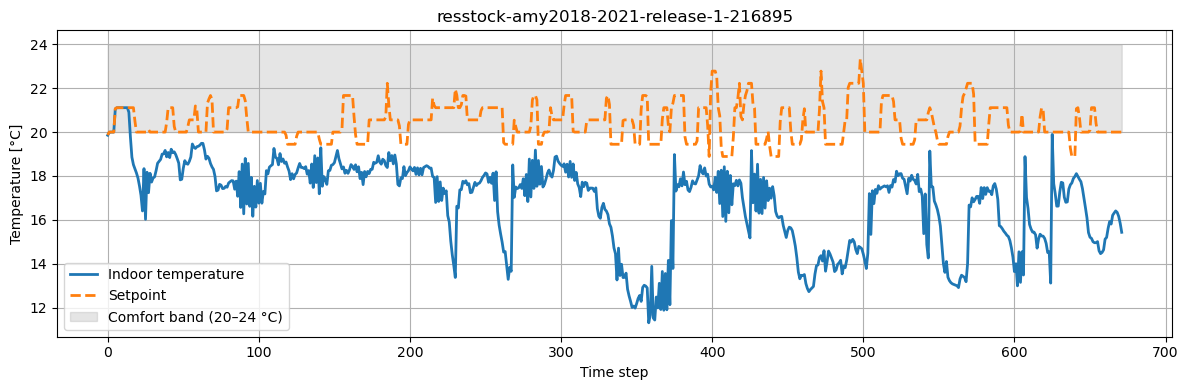

In [40]:
plot_comfort(res_mpc_hvac["env"], building_idx=5)